# Multi commodity demo
Example of how we would use echo to do some optimisation of a building with gas, electrical, and thermal flows

## Import required modules

In [187]:
import networkx as nx
import numpy as np
import pandas as pd

from echo.echo_models import *
from echo.echo_thermal_models import *
from echo.echo_optimiser import *
from echo.objectives import *
from echo.bz_utils import *

## Define some model parameters

In [188]:
time_periods = 24 * 7  # 1 hr intervals for 1 week
interval_duration = 60  # in minutes
expansion_periods = 1  # no planning periods

## Create an electrical load profile and solar generation profile
This data can also be imported from a time series csv

In [189]:
# Define an example load profile, add some noise
load_profile = np.array([100] * time_periods) + np.random.normal(0, 20, time_periods)
# Define a pv system size
solar_system_size = 40  # in kW
# Make up some daily profile (this is purely illustrative)
solar_daily_profile = [0]*7 + [0.2]*1 +[0.4]*1 + [0.8]*2 + [1]*2 + [0.8]*2 + [0.4]*1 + [0.2]*1 + [0]*7
# Repeat this profile over a week
solar_profile = np.array(solar_daily_profile * 7) * solar_system_size * -1
# Take solar offline for first day
solar_profile[0:48] = 0

print(np.average(load_profile))

99.22937756663532


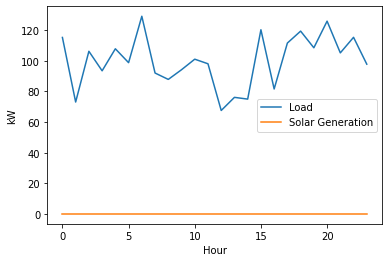

In [190]:
# Plot some of this data
#fig = plt.figure(figsize=(12,8))
plt.plot(load_profile[0:24])
plt.plot(solar_profile[0:24])
plt.legend(['Load', 'Solar Generation'])
plt.xlabel('Hour')
plt.ylabel('kW')
plt.show()

# Define some energy and gas tariffs
For simplicity in this example, let's just use one electricity and one gas tariff

In [191]:
elec_rate_daily = [0.1]*6 + [0.5]*3 + [0.1]*6 + [0.6]*3 + [0.1]*6 # $/kWh
gas_rate_daily = [17] * 24  # $/GJ

# Build echo model
First we build all our ports and nodes, these represent assets

### Build our grid supply node and a connection pt node

In [192]:
bulk_grid_node = Node(node_name='bulk_grid')  # build a node
bulk_grid_node.add_electrical_port('grid') # add an electrical port to connect to

connection_pt_node = TellegenNode(node_name='elec_cp')  # create a 'summing' node to connect all our assets to
connection_pt_node.add_electrical_ports_from_list(['upstream', 'load', 'battery', 'chiller', 'solar'])  # create a port on this node for each asset we will connect

## Create load, battery, and solar assets

In [193]:
# Load node
load_node = Node(node_name='elec_load')
load_port = ElectricalDemand()
load_port.add_demand_profile_from_array(load_profile)  # add our load data in kW to this port - it will become a fixed parameter
load_node.ports['load'] = load_port  # add the port to the node

# Solar node
solar_node = Node(node_name='solar_gen')
solar_port = ElectricalGeneration()
solar_port.add_generation_profile_from_array(solar_profile)
solar_node.ports['solar'] = solar_port

# Battery
battery_node = Node(node_name='battery')
battery_size = 100 # kWh storage capacity
charge_limit = 10  # kW charge/discharge limit
battery_port = ElectricalStorage(max_capacity=battery_size,
                       depth_of_discharge_limit=0,
                       charging_power_limit=charge_limit,
                       discharging_power_limit=-charge_limit,
                       charging_efficiency=1,
                       discharging_efficiency=1,
                       initial_state_of_charge=0.0)
battery_node.ports['battery'] = battery_port

## Create a thermal load with separate heating and cooling ports (because boiler --> heating, chiller --> cooling)

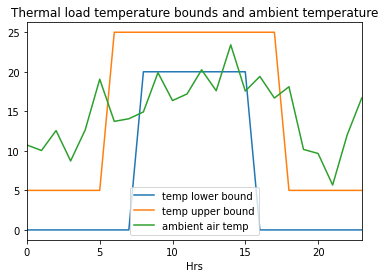

In [194]:
# Create temperature bounds
daily_lb = [0]*8 + [20]*8 + [0]*8
daily_ub = [5]*6 + [25]*12 + [5]*6
ambient_daily = [i for i in range(8, 20)] + [j for j in range(20,8,-1)]
ambient_week = np.array(ambient_daily*7) + np.random.normal(0, 3, time_periods)
# plot these bounds
fig = plt.figure()
plt.plot(daily_lb, label='temp lower bound')
plt.plot(daily_ub, label='temp upper bound')
plt.plot(ambient_week[0:24], label='ambient air temp')
plt.xlabel('Hrs')
plt.xlim([0, 23])
plt.legend()
plt.title('Thermal load temperature bounds and ambient temperature')
plt.show()

In [195]:
# format as dicts
ub_dict = generate_dict_with_pyomo_keys_from_array(daily_ub*7, time_periods)
lb_dict = generate_dict_with_pyomo_keys_from_array(daily_lb*7, time_periods)
ambient_dict = generate_dict_with_pyomo_keys_from_array(ambient_week, time_periods)

thermal_load = ThermalNode(node_name='thermal_load',
                           temp_ub = ub_dict,
                           temp_lb = lb_dict,
                           external_temp = ambient_dict,
                           temp_to_energy_coef=1,
                           loss_factor = 0.05,
                           gain_factor = 0.05,
                           )
# Add separate heating and cooling ports
thermal_load.ports['heating'] = ThermalPort(flows=Flows.Import)
thermal_load.ports['cooling'] = ThermalPort(flows=Flows.Export)

Repeating array across 1 expansion period(s).
Repeating array across 1 expansion period(s).
Repeating array across 1 expansion period(s).


## Create a chiller

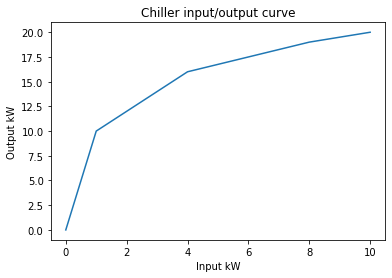

In [196]:
# Chiller node
chiller_node = SimpleChiller(node_name='chiller')

# Define pairs of points that maps chiller input to output. These points form a piecewise approx. of a nonlinear function.
input_breakpoints = [0, 1, 4, 8, 10]
output_values = [0, 10, 16, 19, 20]


# Add these points to the chiller object
chiller_node.add_input_pts(input_breakpoints, time_periods=time_periods, expansion_periods=expansion_periods)
chiller_node.add_output_pts(output_values, time_periods=time_periods, expansion_periods=expansion_periods)

# Plot
plt.plot(input_breakpoints, np.array(output_values))
plt.xlabel('Input kW')
plt.ylabel('Output kW')
plt.title('Chiller input/output curve')
plt.show()

## Create gas components

In [197]:
### GAS
# Gas supply node
bulk_gas_node = Node(node_name='gas_supply')
emission_factor = 60  # 60 kg Co2e/GJ gas
gas_supply_port = FlexPortExport(units=Units.JPS)
emission_port = FlexPortExport(units=Units.CO2)
bulk_gas_node.ports['gas_supply'] = gas_supply_port
bulk_gas_node.ports['emissions'] = emission_port
t = Transform()
t.add_lhs_term(gas_supply_port, TransformRule.Both, 1)
t.add_rhs_term(emission_port, TransformRule.Both, emission_factor)
bulk_gas_node.add_transformation(t)


# Gas CP node
gas_connection_pt_node = TellegenNode(node_name='gas_cp')
gas_connection_pt_node.add_flex_ports_from_list(['upstream', 'boiler'], unit=Units.JPS)

# Create a gas boiler node
gas_boiler = GasBoilerFixedCOP(node_name='gas_boiler',
                               max_input=10,
                               min_input=8,
                               cop=0.8,
                               startup_eta=0.7)

# Node for aggregating carbon emissions
carbon_agg_node = CarbonAggregation(node_name='carbon_agg')
carbon_agg_node.add_flex_port('gas_emissions', unit=Units.CO2)
carbon_agg_node.ports['sum'] = CarbonSink()
carbon_agg_node.add_aggregation_transformation(sum_port_name='sum')

## Create an echo graph and add all our nodes to it

In [198]:
# Create an optimisation graph and add all our nodes to the graph
system = OptimisationGraph()
system.add_node_obj([bulk_grid_node, connection_pt_node, solar_node, chiller_node, battery_node, load_node, thermal_load, bulk_gas_node, carbon_agg_node, gas_connection_pt_node, gas_boiler])

## Next we build all the edges which represent connectivity

In [199]:
# Electrical
system.connect_ports_and_create_edge(bulk_grid_node.ports['grid'], connection_pt_node.ports['upstream'])
system.connect_ports_and_create_edge(connection_pt_node.ports['load'], load_node.ports['load'])
system.connect_ports_and_create_edge(connection_pt_node.ports['battery'], battery_node.ports['battery'])
system.connect_ports_and_create_edge(connection_pt_node.ports['solar'], solar_node.ports['solar'])
system.connect_ports_and_create_edge(connection_pt_node.ports['chiller'], chiller_node.ports['input'])
system.connect_ports_and_create_edge(chiller_node.ports['output'], thermal_load.ports['cooling'])

# Gas
system.connect_ports_and_create_edge(bulk_gas_node.ports['gas_supply'], gas_connection_pt_node.ports['upstream'])
system.connect_ports_and_create_edge(gas_connection_pt_node.ports['boiler'], gas_boiler.ports['input'])
system.connect_ports_and_create_edge(gas_boiler.ports['output'], thermal_load.ports['heating'])

# CO2
system.connect_ports_and_create_edge(bulk_gas_node.ports['emissions'], carbon_agg_node.ports['gas_emissions'])



## Plot our network

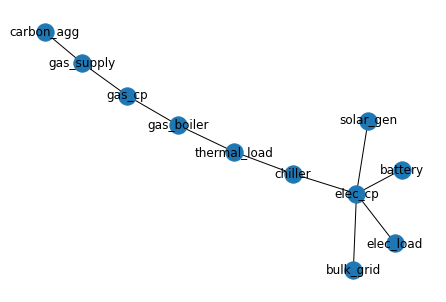

In [200]:
#fig = plt.figure(figsize=(12,8))
pos = nx.spring_layout(system, scale=2)
nx.draw(system, pos, with_labels=True)

## Define tariffs
Now we have a model of the network, which contains some fixed data as well as some optimisable variables.
We can now define some objectives with reference to components in this network
Eg import tariffs on the electrical energy imported from the bulk grid

In [201]:
elec_tariff = ImportTariff(component=connection_pt_node.ports['upstream'],
                           tariff_array=elec_rate_daily*7)

gas_tariff = ImportTariff(component=gas_connection_pt_node.ports['upstream'],
                          tariff_array=gas_rate_daily*7)

We combine these objectives into a set of objectives

In [202]:
# Define a set of objectives
objective_set = ObjectiveSet(objective_list=[elec_tariff, gas_tariff])

## Now we can call the optimiser

In [203]:
optimiser = EchoOptimiser(
    interval_duration=interval_duration,
    number_of_intervals=time_periods,
    number_of_expansion_intervals=expansion_periods,
    discount_rate=0,
    ES=system, # this is our model
    objective_set=objective_set,  # these are our objectives
    profile=None
)

optimiser.optimise(tee=True)  # optimise the example



Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 20.1.0.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2020.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\61405\AppData\Local\Temp\tmpwhllxo6g.cplex.log' open.
CPLEX> Problem 'C:\Users\61405\AppData\Local\Temp\tmpubc891g1.pyomo.lp' read.
Read time = 0.03 sec. (0.67 ticks)
CPLEX> Problem name         : C:\Users\61405\AppData\Local\Temp\tmpubc891g1.pyomo.lp
Objective sense      : Minimize
Variables            :    7057  [Nneg: 2017,  Box: 840,  Free: 1848,
                                 Binary: 1008,  Other: 1344]
Objective nonzeros   :     336
Linear constraints   :    6385  [Less: 2184,  Equal: 4201]
  Nonzeros           :   16126
  RHS nonzeros       :    1563
SOS                  :   

In [204]:
print(optimiser.opt_status)


Status: ok
User time: 0.55
Termination condition: optimal
Termination message: MIP - Integer optimal, tolerance (0.0001/1e-06)\x3a Objective = 5.7955448158e+03
Statistics: 
  Branch and bound: 
    Number of bounded subproblems: 409
    Number of created subproblems: 409
Error rc: 0
Time: 0.7997498512268066



### Look at some results

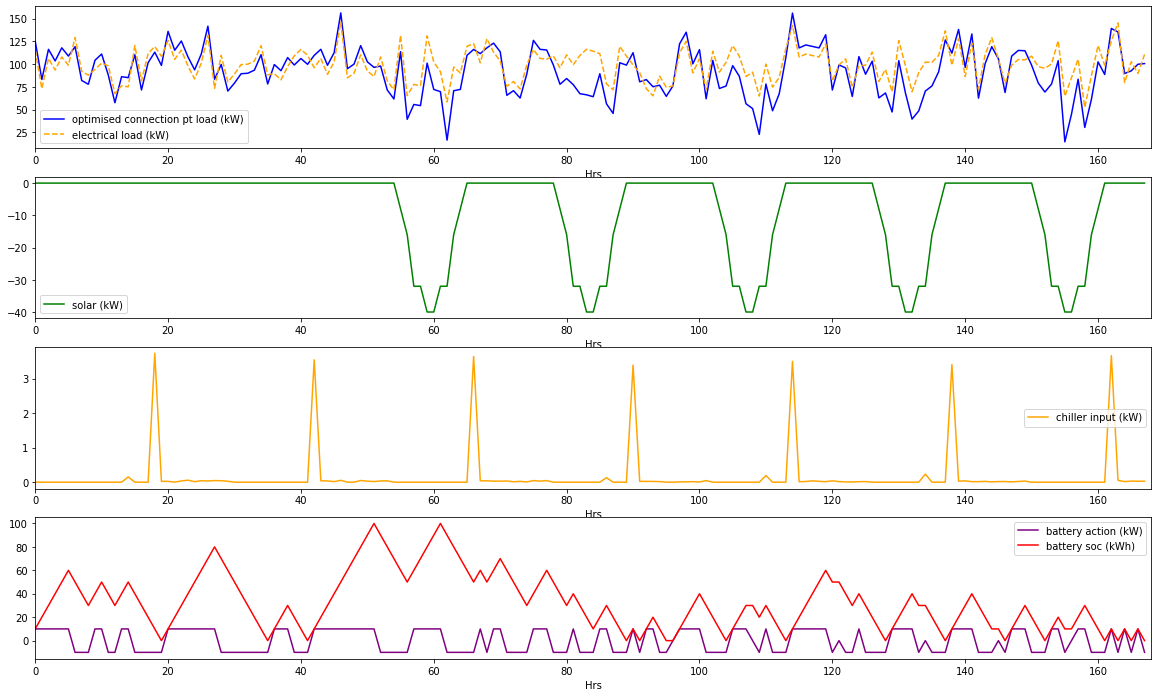

In [205]:
# ## Plot the optimised connection point
# plt.plot(elec_rate_daily*7, label='import_tariff')
# plt.xlabel('Hrs')
# plt.legend()
# plt.show()

fig = plt.figure(figsize=(20, 12))
ax1 = fig.add_subplot(4, 1, 1)
ax1.plot(optimiser.values(connection_pt_node.ports['upstream'].port_name), label='optimised connection pt load (kW)', color='blue')
ax1.plot(optimiser.values(load_port.port_name), '--', label='electrical load (kW)', color='orange')
plt.xlabel('Hrs')
plt.xlim([0,time_periods])
plt.legend()

ax2 = fig.add_subplot(4, 1, 2)
ax2.plot(optimiser.values(solar_port.port_name), label='solar (kW)', color='green')
plt.xlabel('Hrs')
plt.xlim([0,time_periods])
plt.legend()

ax3 = fig.add_subplot(4, 1, 3)
ax3.plot(optimiser.values(chiller_node.ports['input'].port_name), label='chiller input (kW)', color='orange')
plt.xlabel('Hrs')
plt.xlim([0,time_periods])
plt.legend()

ax4 = fig.add_subplot(4, 1, 4)
ax4.plot(optimiser.values(battery_port.port_name), label='battery action (kW)', color='purple')
ax4.plot(optimiser.values(battery_port.soc_value), label='battery soc (kWh)', color='red')
plt.xlabel('Hrs')
plt.xlim([0,time_periods])
plt.legend()

plt.show()

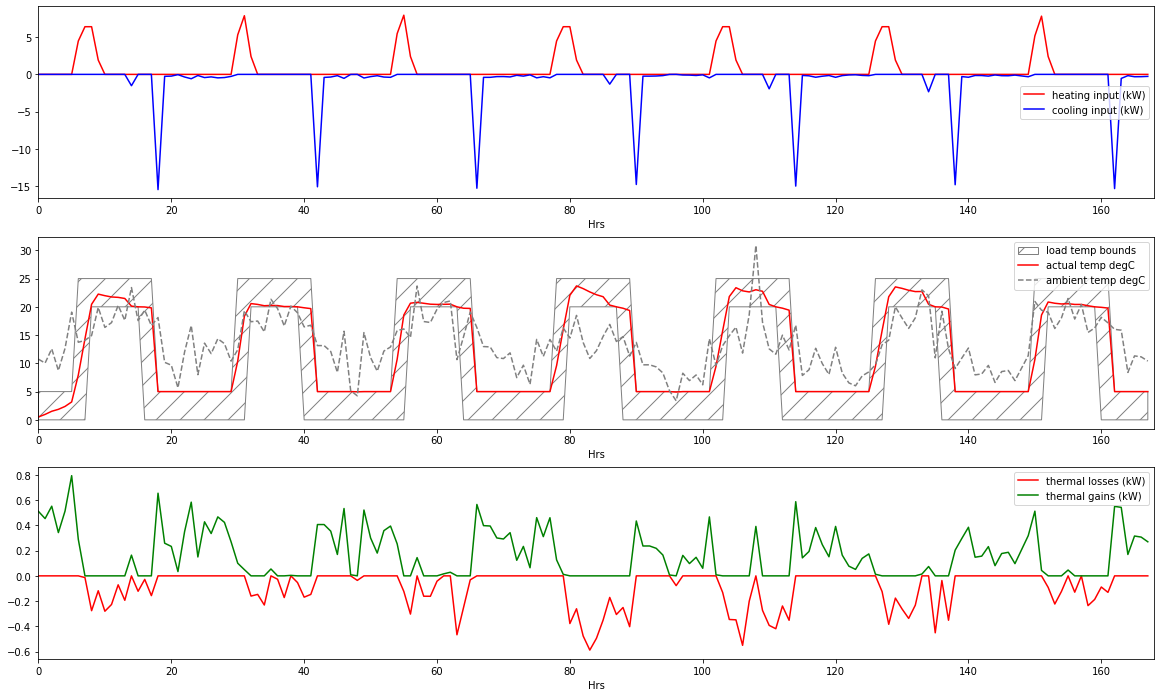

In [206]:
# Thermal plots
hrs = [i for i in range(time_periods)]
fig = plt.figure(figsize=(20, 12))
ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(optimiser.values(thermal_load.ports['heating'].port_name), label='heating input (kW)', color='red')
ax1.plot(optimiser.values(thermal_load.ports['cooling'].port_name), label='cooling input (kW)', color='blue')
plt.xlabel('Hrs')
plt.xlim([0,time_periods])
plt.legend()

ax2 = fig.add_subplot(3, 1, 2)
ax2.fill_between(hrs, daily_lb*7, daily_ub*7, color='none', edgecolor='grey', hatch='/', label='load temp bounds')
ax2.plot(optimiser.values(thermal_load.internal_temp), label='actual temp degC', color='red')
ax2.plot(ambient_week, '--', label='ambient temp degC', color='grey')
plt.xlabel('Hrs')
plt.xlim([0,time_periods])
plt.legend()

ax3 = fig.add_subplot(3, 1, 3)
ax3.plot(optimiser.values(thermal_load.losses)*thermal_load.loss_factor, label='thermal losses (kW)', color='red')
ax3.plot(optimiser.values(thermal_load.gains)*thermal_load.gain_factor, label='thermal gains (kW)', color='green')
plt.xlabel('Hrs')
plt.xlim([0,time_periods])
plt.legend()

plt.show()

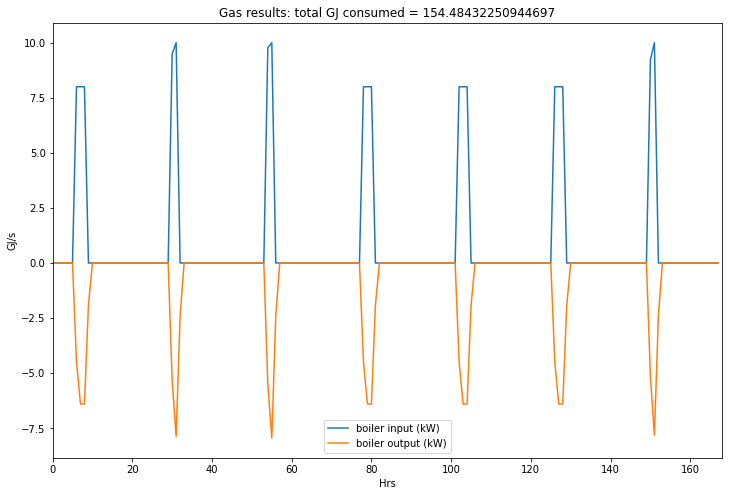

In [207]:
fig = plt.figure(figsize=(12,8))
plt.plot(optimiser.values(gas_boiler.ports['input'].port_name), label='boiler input (kW)')
plt.plot(optimiser.values(gas_boiler.ports['output'].port_name), label='boiler output (kW)')
plt.xlabel('Hrs')
plt.ylabel('GJ/s')
plt.xlim([0,time_periods])
plt.title('Gas results: total GJ consumed = {}'.format(sum(optimiser.values(gas_boiler.ports['input'].port_name))))
plt.legend()
plt.show()

In [208]:
# fig = plt.figure(figsize=(12,8))
# plt.plot(optimiser.values(heating_port.internal_temp), label='heating load internal temp degC')
# plt.plot(optimiser.values(gas_boiler.ports['input'].port_name), label='boiler input')
# plt.plot(optimiser.values(gas_boiler.ports['output'].port_name), label='boiler output')
# plt.xlabel('Hrs')
# plt.legend()
# plt.show()

In [209]:
print('Total emissions: ', sum(optimiser.values(carbon_agg_node.ports['sum'].port_name)))

Total emissions:  2.574738708490783


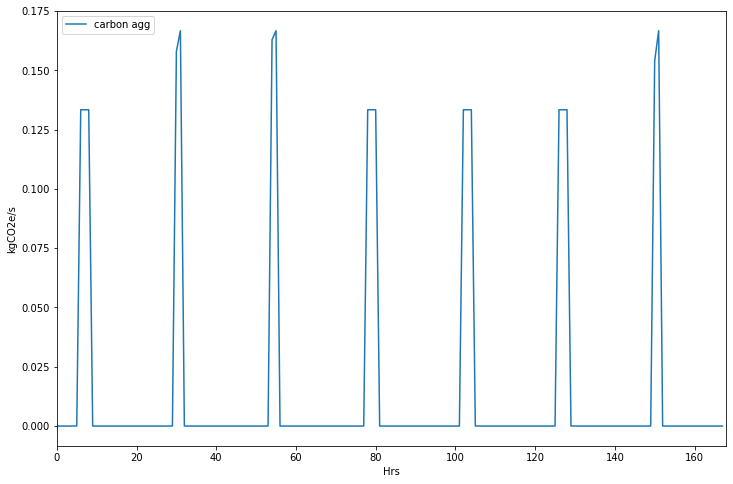

In [210]:
fig = plt.figure(figsize=(12,8))
plt.plot(optimiser.values(carbon_agg_node.ports['sum'].port_name), label='carbon agg')
plt.xlabel('Hrs')
plt.ylabel('kgCO2e/s')
plt.xlim([0,time_periods])
plt.legend()
plt.show()